In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from joblib import Parallel, delayed

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.ticker as mtick
# import matplotlib as mpl

import scienceplots
# plt.style.use(['science', 'vibrant'])
plt.style.use(['science'])
plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.figsize'] = (3.0, 2.625)
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 8
plt.rcParams.update({'font.size': 10})
colors = plt.colormaps['tab20']

from src import *

# Utils

In [3]:
# Dice loss function on binary numbers
dice_loss = lambda y, y_hat: 1 - 2 * bin(y & y_hat).count("1") / (bin(y).count("1") + bin(y_hat).count("1") + 1e-3)

# Confidence Estimators
def SDC(y_hat, hatPyi_x):
    # y_hat_ = int2img(y_hat, n=n).flatten()
    # return 2 * (y_hat_ * hatPyi).sum() / (np.sum(y_hat_) + hatPyi.sum())
    n = hatPyi_x.shape[0]
    tp = np.where([yi_hat == '1' for yi_hat in np.binary_repr(y_hat, width=n)], hatPyi_x, 0).sum()
    return 2 * tp / (bin(y_hat).count("1") + hatPyi_x.sum())

def aMSP(y_hat, hatPyi_x):
    n = hatPyi_x.shape[0]
    return np.where([yi_hat == '1' for yi_hat in np.binary_repr(y_hat, width=n)], hatPyi_x, 1-hatPyi_x).mean()


In [4]:
import pickle

# with open("results.pkl", "wb") as f:
#     pickle.dump(results, f)

# Progressively smaller foreground ratio

## Ideal Model

In [ ]:
[0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 0.75]

In [7]:
%%time

N = 1000  # number of images
n = 10

# number of pixels
def compute_for_foreground(f=0.5):
    # marginal probabilities
    mean_logit = sp.special.logit(f)
    Pyi = np.array([sp.special.expit(np.random.RandomState(2**n + x - 1).normal(mean_logit, scale=5, size=n)) for x in range(N)])

    h = lambda x: ((2**np.arange(n)[::-1]) * (Pyi[x] >= 0.5)).sum()

    Y_pred = np.vectorize(h)(np.arange(N))

    # image-level output probability derived from pixel-level probabilities
    def get_Py_x(y, x, Pyi=Pyi):
        y_probs = np.where([yi == '1' for yi in np.binary_repr(y, width=n)], Pyi[x], 1 - Pyi[x])
        return np.prod(y_probs)

    def r_y_x(y, x):
        y_pred = Y_pred[x]
        return dice_loss(y, y_pred) * get_Py_x(y, x)

    def r(x):
        return np.vectorize(lambda y: r_y_x(y, x))(np.arange(2**n)).sum()

    R_x = np.vectorize(r)(np.arange(N))  # conditional risk

    return {
        "f": f,
        "Pyi": Pyi,
        "R_x": R_x,
    }

f_values = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 0.75]
results = Parallel(n_jobs=-1)(delayed(compute_for_foreground)(f) for f in f_values)

CPU times: user 51.3 ms, sys: 88.1 ms, total: 139 ms
Wall time: 7.3 s


In [ ]:
# with open("results.pkl", "rb") as f:
#     results = pickle.load(f)

# N = 1000

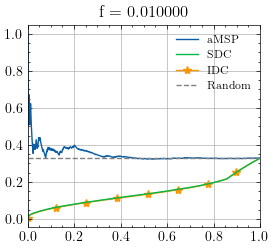

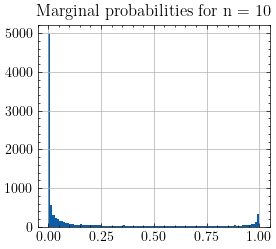

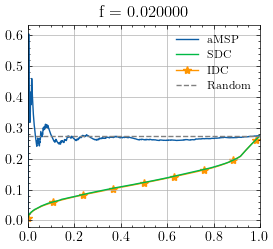

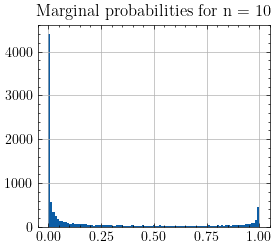

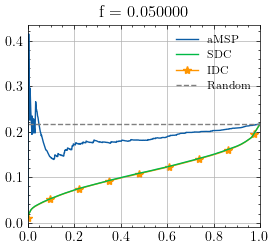

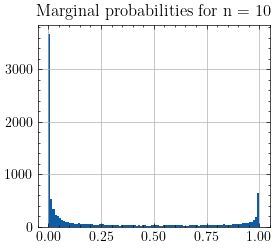

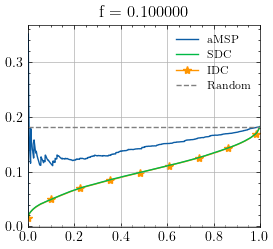

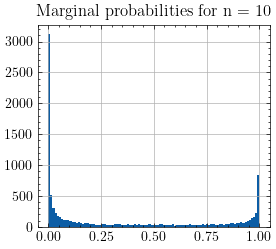

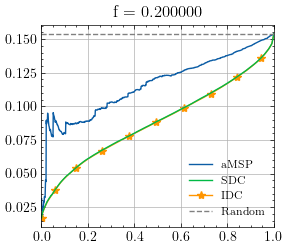

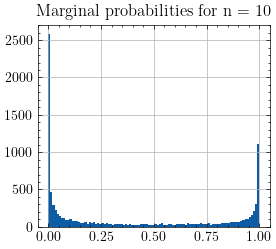

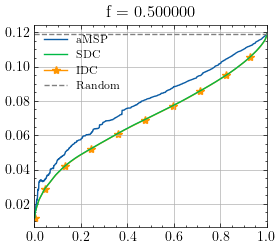

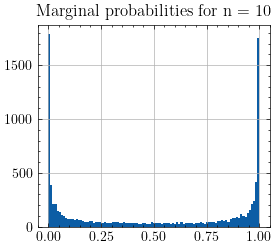

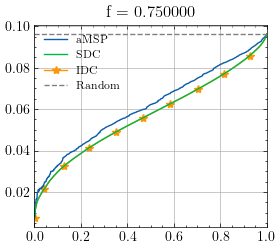

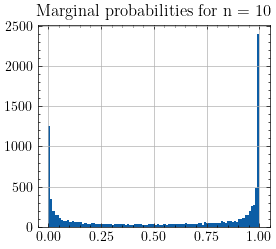

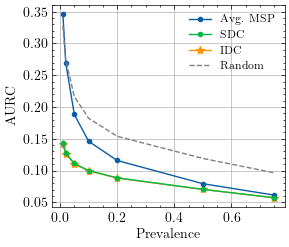

In [11]:
risks = list()
idc_aucs = list()
sdc_aucs = list()
msp_aucs = list()
fs = list()
for result in results:
    f = result["f"]
    Pyi = result["Pyi"]
    R_x = result["R_x"]

    h_hat = lambda x: ((2**np.arange(n)[::-1]) * (Pyi[x] >= 0.5)).sum()
    Y_hat = np.vectorize(h_hat)(np.arange(N))

    msp_risks, msp_coverages = rc_curve_(R_x, np.vectorize(lambda x: aMSP(Y_hat[x], Pyi[x]))(np.arange(N)))
    msp_auc = auc(msp_coverages, msp_risks)
    msp_aucs.append(msp_auc)
    plt.plot(msp_coverages, msp_risks, label=f"aMSP")

    sdc_risks, sdc_coverages = rc_curve_(R_x, np.vectorize(lambda x: SDC(Y_hat[x], Pyi[x]))(np.arange(N)))
    sdc_auc = auc(sdc_coverages, sdc_risks)
    sdc_aucs.append(sdc_auc)
    plt.plot(sdc_coverages, sdc_risks, label=f"SDC")

    idc_risks, idc_coverages = rc_curve_(R_x, -R_x)
    idc_auc = auc(idc_coverages, idc_risks)
    idc_aucs.append(idc_auc)
    plt.plot(idc_coverages, idc_risks, marker="*", markevery=0.10, zorder=-1, label="IDC")

    plt.hlines(idc_risks[-1], 0, 1, linestyles='--', colors='grey', label="Random")

    plt.title("f = %f" % f)
    plt.xlim(0,1)
    plt.legend()
    plt.show()

    plt.hist(Pyi.flatten(), bins=np.linspace(0,1,100))
    # plt.yscale('log')
    plt.title("Marginal probabilities for n = %d" % n)
    plt.show()

    random_risk = idc_risks[-1]
    risks.append(random_risk)

    fs.append(f)

plt.plot(fs, msp_aucs, marker=".", label="Avg. MSP")
plt.plot(fs, sdc_aucs, marker=".", label="SDC")
plt.plot(fs, idc_aucs, marker="*", zorder=-1, label="IDC")
plt.plot(fs, risks, "--", c="grey", label="Random")
# plt.xlim(0, 0.4)
# plt.ylim(0, 0.4)
plt.xlabel("Prevalence")
plt.ylabel("AURC")
# plt.xscale('log')
plt.legend()
plt.savefig("aurc_prev.pdf")
plt.show()

## Perturbed Model

In [26]:
%%time

N = 1000  # number of images

# number of pixels
def compute_for_n(n):
    # marginal probabilities
    Pyi = np.array([sp.special.expit(np.random.RandomState(2**n + x - 1).normal(0, scale=5, size=n)) for x in range(N)])

    def hatpyi(x, scale=2.0):
        z = sp.special.logit(Pyi[x])
        zhat = np.random.RandomState(2*2**n + x - 1).normal(z, scale=scale)
        return sp.special.expit(zhat)

    hatPyi = np.vstack([hatpyi(x) for x in np.arange(N)])

    h_hat = lambda x: ((2**np.arange(n)[::-1]) * (hatPyi[x] >= 0.5)).sum()

    Y_hat = np.vectorize(h_hat)(np.arange(N))

    # image-level output probability derived from pixel-level probabilities
    def get_Py_x(y, x, Pyi=Pyi):
        y_probs = np.where([yi == '1' for yi in np.binary_repr(y, width=n)], Pyi[x], 1 - Pyi[x])
        return np.prod(y_probs)

    def r_y_x(y, x):
        y_hat = Y_hat[x]
        return dice_loss(y, y_hat) * get_Py_x(y, x)

    def r(x):
        return np.vectorize(lambda y: r_y_x(y, x))(np.arange(2**n)).sum()

    R_x = np.vectorize(r)(np.arange(N))  # conditional risk

    return {
        "n": n,
        "Pyi": Pyi,
        "hatPyi": hatPyi,
        "R_x": R_x,
    }

results = Parallel(n_jobs=-1)(delayed(compute_for_n)(n) for n in np.arange(1, 15, 2))

CPU times: user 43.4 ms, sys: 59.6 ms, total: 103 ms
Wall time: 1min 8s


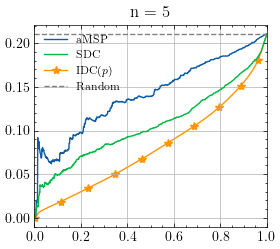

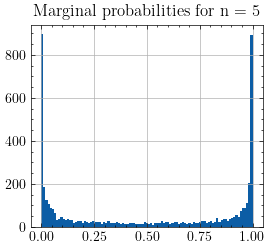

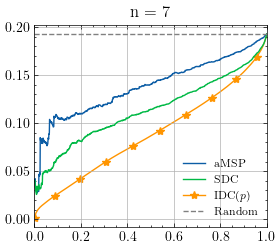

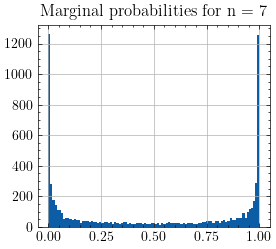

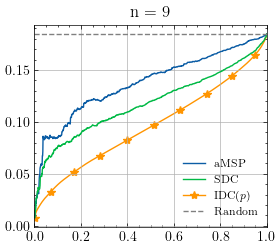

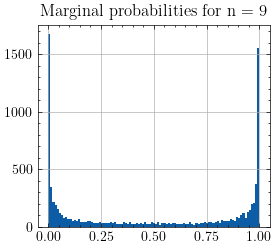

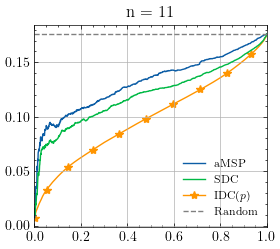

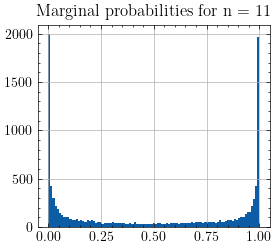

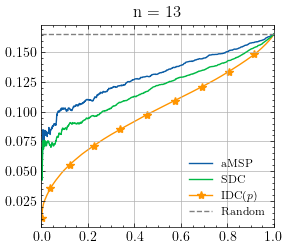

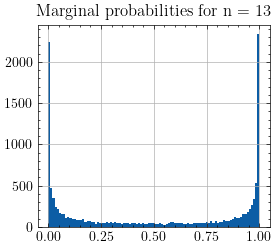

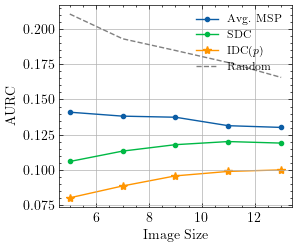

In [28]:
risks = list()
idc_aucs = list()
# hidc_aucs = list()
sdc_aucs = list()
msp_aucs = list()
ns = list()
for result in results:
    n = result["n"]
    Pyi = result["Pyi"]
    hatPyi = result["hatPyi"]
    R_x = result["R_x"]

    assert R_x.shape[0] == N
    assert n == Pyi.shape[1]

    if n < 5:
        continue

    h_hat = lambda x: ((2**np.arange(n)[::-1]) * (hatPyi[x] >= 0.5)).sum()

    Y_hat = np.vectorize(h_hat)(np.arange(N))

    msp_risks, msp_coverages = rc_curve_(R_x, np.vectorize(lambda x: aMSP(Y_hat[x], hatPyi[x]))(np.arange(N)))
    msp_auc = auc(msp_coverages, msp_risks)
    msp_aucs.append(msp_auc)
    plt.plot(msp_coverages, msp_risks, label=f"aMSP")

    sdc_risks, sdc_coverages = rc_curve_(R_x, np.vectorize(lambda x: SDC(Y_hat[x], hatPyi[x]))(np.arange(N)))
    sdc_auc = auc(sdc_coverages, sdc_risks)
    sdc_aucs.append(sdc_auc)
    plt.plot(sdc_coverages, sdc_risks, label=f"SDC")

    idc_risks, idc_coverages = rc_curve_(R_x, -R_x)
    idc_auc = auc(idc_coverages, idc_risks)
    idc_aucs.append(idc_auc)
    plt.plot(idc_coverages, idc_risks, marker="*", markevery=0.10, zorder=-1, label="IDC($p$)")

    # hidc_risks, hidc_coverages = rc_curve_(R_x, -R_x)
    # hidc_auc = auc(hidc_coverages, hidc_risks)
    # hidc_aucs.append(hidc_auc)
    # plt.plot(hidc_coverages, hidc_risks, marker="*", markevery=0.10, zorder=-1, label="IDC($\hat{p}$)")

    plt.hlines(idc_risks[-1], 0, 1, linestyles='--', colors='grey', label="Random")

    plt.title("n = %d" % n)
    plt.xlim(0,1)
    plt.legend()
    plt.show()

    plt.hist(Pyi.flatten(), bins=np.linspace(0,1,100))
    # plt.yscale('log')
    plt.title("Marginal probabilities for n = %d" % n)
    plt.show()

    random_risk = idc_risks[-1]
    risks.append(random_risk)

    ns.append(n)

plt.plot(ns, msp_aucs, marker=".", label="Avg. MSP")
plt.plot(ns, sdc_aucs, marker=".", label="SDC")
plt.plot(ns, idc_aucs, marker="*", zorder=-1, label="IDC($p$)")
# plt.plot(ns, hidc_aucs, marker=".", zorder=-1, label="IDC($\hat{p}$)")
plt.plot(ns, risks, "--", c="grey", label="Random")
# plt.xlim(0, 0.4)
# plt.ylim(0, 0.4)
plt.xlabel("Image Size")
plt.ylabel("AURC")
plt.legend()
# plt.savefig("aurc_n.pdf")
plt.show()